# 01 - 感知机与神经网络

> 配套教程：`04_deep_learning/01_perceptron_nn.py`

本节从最简单的感知机开始，一步步构建一个完整的神经网络。它是深度学习的入口：你会看到“神经元如何计算”“为什么需要隐藏层”“反向传播在算什么”“为什么神经网络能解决非线性问题”。

## 本 Notebook 概览

| 章节 | 内容 | 关键概念 |
|------|------|----------|
| 1 | 感知机 | 单个神经元、线性打分、激活函数 |
| 2 | 多层感知机 MLP | 隐藏层、非线性表达能力 |
| 3 | 反向传播 | 链式法则、梯度从后往前传 |
| 4 | 从零实现神经网络 | 前向传播、反向传播、参数更新 |
| 5 | 非线性分类 | XOR、月牙数据、决策边界 |
| 6 | 梯度检验 | 数值梯度、验证反向传播 |

学习建议：不要一开始就把神经网络想得很神秘。先把它看成“很多个逻辑回归单元组合起来”，再理解隐藏层如何学习中间特征。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager


def configure_chinese_font():
    preferred_fonts = [
        "Noto Sans CJK SC", "Noto Sans CJK JP", "Source Han Sans SC",
        "WenQuanYi Zen Hei", "WenQuanYi Micro Hei", "SimHei",
        "Microsoft YaHei", "PingFang SC", "Arial Unicode MS",
    ]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
            plt.rcParams["font.family"] = "sans-serif"
            print(f"Matplotlib 中文字体: {font_name}")
            return font_name
    print("未检测到可用中文字体，中文图表可能显示为方框。")
    return None


CHINESE_FONT = configure_chinese_font()
plt.rcParams["axes.unicode_minus"] = False
np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("第四章 4.1：感知机与神经网络")
print("环境准备完毕")

Matplotlib 中文字体: Noto Sans CJK JP
第四章 4.1：感知机与神经网络
环境准备完毕


## 1. 感知机：一个最小神经元

单个感知机的计算分两步：

$$z=w_1x_1+w_2x_2+\cdots+w_nx_n+b$$

$$a=f(z)$$

其中：

- $x_i$ 是输入特征。
- $w_i$ 是权重，决定每个特征的重要性和方向。
- $b$ 是偏置，控制整体阈值。
- $f$ 是激活函数，用来决定输出形式。

如果激活函数是 Sigmoid，这个结构就和逻辑回归非常接近。区别是神经网络会把很多神经元排成层，并堆叠多层。

### 为什么 XOR 是经典例子

XOR 的规则是“两者不同则为 1，两者相同则为 0”。它不能用一条直线分开，因此单层线性模型解决不了。

XOR 真值表:
  x1  x2  ->  y
   0   0   ->  0
   0   1   ->  1
   1   0   ->  1
   1   1   ->  0


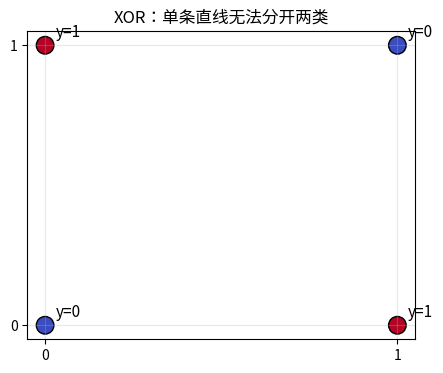

In [2]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

print("XOR 真值表:")
print("  x1  x2  ->  y")
for x_row, target in zip(X_xor, y_xor):
    print(f"   {x_row[0]}   {x_row[1]}   ->  {target}")

plt.figure(figsize=(5, 4))
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap="coolwarm", s=160, edgecolor="black")
for x_row, target in zip(X_xor, y_xor):
    plt.text(x_row[0] + 0.03, x_row[1] + 0.03, f"y={target}", fontsize=11)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.title("XOR：单条直线无法分开两类")
plt.grid(alpha=0.3)
plt.show()

## 2. 多层感知机 MLP：隐藏层带来非线性

多层感知机的结构是：

```text
输入层 -> 隐藏层 -> 输出层
```

每一层做两件事：

$$z=XW+b$$

$$a=activation(z)$$

关键点：如果没有激活函数，多层线性变换仍然等价于一层线性变换。例如：

$$W_2(W_1x)=Wx$$

所以隐藏层真正有用，是因为 ReLU、Sigmoid、Tanh 等激活函数引入了非线性。非线性让网络能把空间弯折、组合、重新表示，从而解决 XOR 和月牙形数据。

常用激活函数：

- **ReLU**：$\max(0,x)$，隐藏层最常用。
- **Sigmoid**：输出 $(0,1)$，常用于二分类输出层。
- **Tanh**：输出 $(-1,1)$，早期 RNN 常用。
- **Softmax**：输出多类概率分布。

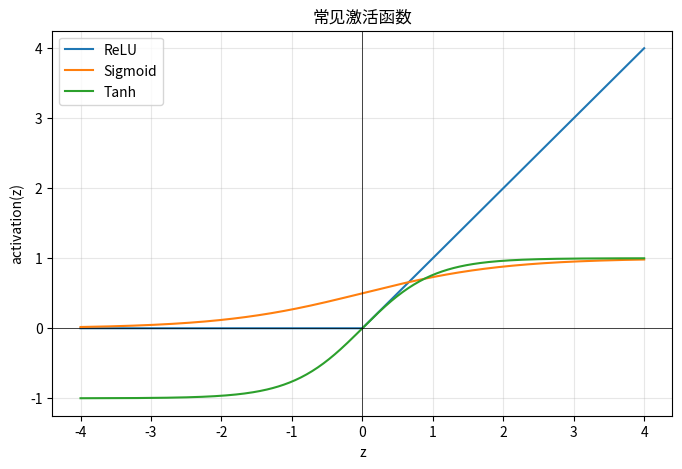

In [3]:
z = np.linspace(-4, 4, 400)
relu = np.maximum(0, z)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)

plt.figure(figsize=(8, 5))
plt.plot(z, relu, label="ReLU")
plt.plot(z, sigmoid, label="Sigmoid")
plt.plot(z, tanh, label="Tanh")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title("常见激活函数")
plt.xlabel("z")
plt.ylabel("activation(z)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 3. 反向传播：链式法则的系统应用

两层网络的前向传播：

$$z_1=XW_1+b_1$$
$$a_1=ReLU(z_1)$$
$$z_2=a_1W_2+b_2$$
$$\hat y=\sigma(z_2)$$

反向传播从损失开始，逐层计算梯度：

- 输出层误差：$dz_2=\hat y-y$。
- 第二层权重梯度：$dW_2=a_1^Tdz_2/n$。
- 传回隐藏层：$da_1=dz_2W_2^T$。
- 经过 ReLU 导数：$dz_1=da_1\odot ReLU'(z_1)$。
- 第一层权重梯度：$dW_1=X^Tdz_1/n$。

初学者可以把反向传播理解为：每层都回答“我对最终错误贡献了多少，应该往哪个方向改”。

## 4. 从零实现两层神经网络

下面实现原始教程中的两层网络：

```text
输入 -> 隐藏层(ReLU) -> 输出层(Sigmoid)
```

使用 He 初始化给 ReLU 层设置权重，使用二分类交叉熵作为损失。代码里保留中间变量 `z1`、`a1`、`z2`、`a2`，是为了反向传播时复用。

In [4]:
class NeuralNetwork:
    """从零实现的两层神经网络：输入 -> ReLU 隐藏层 -> Sigmoid 输出层。"""

    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.lr = learning_rate
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        self.losses = []

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        n = X.shape[0]
        y = y.reshape(-1, 1)
        dz2 = self.a2 - y
        dW2 = self.a1.T @ dz2 / n
        db2 = np.sum(dz2, axis=0, keepdims=True) / n
        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_derivative(self.z1)
        dW1 = X.T @ dz1 / n
        db1 = np.sum(dz1, axis=0, keepdims=True) / n

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def compute_loss(self, y_true, y_pred):
        y_true = y_true.reshape(-1, 1)
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self, X, y, epochs=1000, verbose=True):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)
            self.backward(X, y)
            if verbose and (epoch % 200 == 0 or epoch == epochs - 1):
                acc = np.mean((y_pred.flatten() >= 0.5).astype(int) == y)
                print(f"  Epoch {epoch:4d}: loss={loss:.4f}, accuracy={acc:.4f}")
        return self

    def predict(self, X):
        probs = self.forward(X)
        return (probs.flatten() >= 0.5).astype(int)

## 5. 解决 XOR 和月牙形非线性分类

单层模型无法解决 XOR，但包含隐藏层的神经网络可以。隐藏层会学习一种中间表示，让原本不能线性分开的数据在新表示空间中变得更容易分开。

In [5]:
print("--- 用神经网络解决 XOR ---")
np.random.seed(42)
nn_xor = NeuralNetwork(input_size=2, hidden_size=4, output_size=1, learning_rate=0.5)
nn_xor.fit(X_xor, y_xor, epochs=2000)

predictions = nn_xor.predict(X_xor)
print("\nXOR 预测结果:")
for x_row, pred, target in zip(X_xor, predictions, y_xor):
    print(f"  {x_row.tolist()} -> 预测: {pred}, 真实: {target}")

assert np.array_equal(predictions, y_xor)
print("✓ 神经网络成功解决 XOR 问题！")

--- 用神经网络解决 XOR ---
  Epoch    0: loss=0.8147, accuracy=0.2500
  Epoch  200: loss=0.0811, accuracy=1.0000
  Epoch  400: loss=0.0192, accuracy=1.0000
  Epoch  600: loss=0.0100, accuracy=1.0000
  Epoch  800: loss=0.0067, accuracy=1.0000
  Epoch 1000: loss=0.0050, accuracy=1.0000
  Epoch 1200: loss=0.0039, accuracy=1.0000
  Epoch 1400: loss=0.0032, accuracy=1.0000
  Epoch 1600: loss=0.0027, accuracy=1.0000
  Epoch 1800: loss=0.0024, accuracy=1.0000
  Epoch 1999: loss=0.0021, accuracy=1.0000

XOR 预测结果:
  [0, 0] -> 预测: 0, 真实: 0
  [0, 1] -> 预测: 1, 真实: 1
  [1, 0] -> 预测: 1, 真实: 1
  [1, 1] -> 预测: 0, 真实: 0
✓ 神经网络成功解决 XOR 问题！


In [6]:
print("--- 解决月牙形非线性分类 ---")
X_moon, y_moon = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_moon, y_moon, test_size=0.2, random_state=42)

mean = X_train_m.mean(axis=0)
std = X_train_m.std(axis=0)
X_train_m = (X_train_m - mean) / std
X_test_m = (X_test_m - mean) / std

np.random.seed(42)
nn_moon = NeuralNetwork(input_size=2, hidden_size=16, output_size=1, learning_rate=0.1)
nn_moon.fit(X_train_m, y_train_m, epochs=2000)

y_pred_moon = nn_moon.predict(X_test_m)
acc_moon = accuracy_score(y_test_m, y_pred_moon)
print(f"\n测试准确率: {acc_moon:.4f}")
assert acc_moon > 0.85
print("✓ 神经网络成功解决非线性分类问题！")

--- 解决月牙形非线性分类 ---
  Epoch    0: loss=1.1826, accuracy=0.2800
  Epoch  200: loss=0.2689, accuracy=0.8625
  Epoch  400: loss=0.2453, accuracy=0.8825
  Epoch  600: loss=0.2120, accuracy=0.9200
  Epoch  800: loss=0.1772, accuracy=0.9450
  Epoch 1000: loss=0.1464, accuracy=0.9550
  Epoch 1200: loss=0.1215, accuracy=0.9650
  Epoch 1400: loss=0.1031, accuracy=0.9725
  Epoch 1600: loss=0.0901, accuracy=0.9750
  Epoch 1800: loss=0.0809, accuracy=0.9775
  Epoch 1999: loss=0.0743, accuracy=0.9750

测试准确率: 0.9800
✓ 神经网络成功解决非线性分类问题！


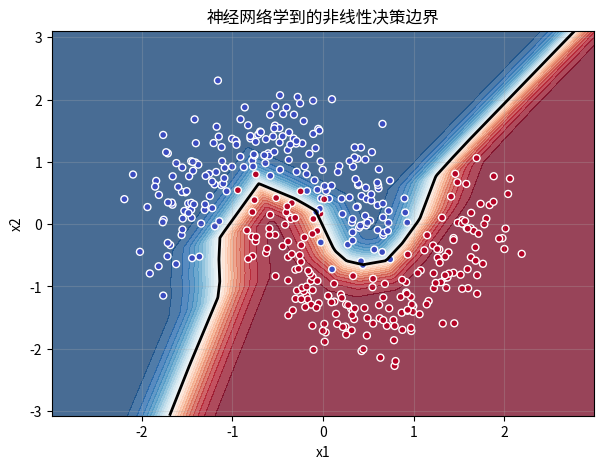

In [7]:
x_min, x_max = X_train_m[:, 0].min() - 0.8, X_train_m[:, 0].max() + 0.8
y_min, y_max = X_train_m[:, 1].min() - 0.8, X_train_m[:, 1].max() + 0.8
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.column_stack([xx.ravel(), yy.ravel()])
proba = nn_moon.forward(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, proba, levels=30, cmap="RdBu_r", alpha=0.75)
plt.contour(xx, yy, proba, levels=[0.5], colors="black", linewidths=2)
plt.scatter(X_train_m[:, 0], X_train_m[:, 1], c=y_train_m, cmap="coolwarm", s=25, edgecolor="white")
plt.title("神经网络学到的非线性决策边界")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.25)
plt.show()

## 6. 梯度检验：验证反向传播实现

手写反向传播很容易出错。梯度检验用数值方法近似梯度：

$$\frac{\partial L}{\partial \theta}\approx\frac{L(\theta+\epsilon)-L(\theta-\epsilon)}{2\epsilon}$$

如果数值梯度和解析梯度接近，说明反向传播大概率实现正确。

In [8]:
np.random.seed(7)
nn_check = NeuralNetwork(input_size=2, hidden_size=3, output_size=1, learning_rate=0.01)
X_check = np.random.randn(5, 2)
y_check = np.array([0, 1, 1, 0, 1])

epsilon = 1e-5
original_val = nn_check.W1[0, 0]

nn_check.W1[0, 0] = original_val + epsilon
loss_plus = nn_check.compute_loss(y_check, nn_check.forward(X_check))

nn_check.W1[0, 0] = original_val - epsilon
loss_minus = nn_check.compute_loss(y_check, nn_check.forward(X_check))

numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)

nn_check.W1[0, 0] = original_val
nn_check.forward(X_check)
n = X_check.shape[0]
y_r = y_check.reshape(-1, 1)
dz2 = nn_check.a2 - y_r
da1 = dz2 @ nn_check.W2.T
dz1 = da1 * nn_check.relu_derivative(nn_check.z1)
dW1 = X_check.T @ dz1 / n
analytical_grad = dW1[0, 0]

relative_diff = abs(numerical_grad - analytical_grad) / (abs(numerical_grad) + 1e-8)
print(f"数值梯度: {numerical_grad:.8f}")
print(f"解析梯度: {analytical_grad:.8f}")
print(f"相对差异: {relative_diff:.2e}")
assert relative_diff < 1e-5
print("✓ 梯度检验通过")

数值梯度: -0.00002835
解析梯度: -0.00002835
相对差异: 1.62e-07
✓ 梯度检验通过


## 7. 总结与练习

关键要点：

1. 单个神经元 = 线性变换 + 激活函数。
2. 多层网络必须有非线性激活，否则仍然等价于线性模型。
3. 前向传播负责计算预测，反向传播负责计算梯度。
4. 隐藏层可以学习中间表示，从而解决非线性分类。
5. 梯度检验是验证手写反向传播的好方法。

**练习**：改变隐藏层大小、学习率、训练轮数，观察 XOR 和月牙数据的训练效果。

## 8. 深入理解：隐藏层到底学到了什么

初学神经网络时，最容易把隐藏层看成“黑盒”。其实隐藏层可以理解为自动学习的新特征。

以月牙形数据为例，原始输入只有二维坐标 $(x_1,x_2)$。逻辑回归只能在这个二维平面上画一条直线，所以面对弯曲边界会吃力。隐藏层会把原始坐标变换成一组新的表示：

$$h=ReLU(XW_1+b_1)$$

这些隐藏单元可以分别响应空间中的不同区域。输出层再把这些隐藏单元组合起来，就能形成弯曲边界。

因此，“神经网络能处理非线性”的关键不是某个单独神经元很强，而是许多简单神经元组合后能表达复杂函数。

### 宽度和深度的直觉

- **更宽**：同一层中有更多神经元，可以同时检测更多模式。
- **更深**：可以把简单模式逐层组合成复杂模式。
- **更复杂不总是更好**：模型越大，越需要更多数据、正则化和验证集监控。

## 9. 常见误区与调试建议

### 误区 1：训练不动就是模型不够大

不一定。训练不动可能来自学习率太小、初始化不好、激活函数饱和、梯度实现错误，或者输入没有标准化。

### 误区 2：训练准确率越高越好

训练准确率很高但测试准确率低，往往是过拟合。深度学习里需要同时观察训练集和验证/测试集。

### 误区 3：反向传播必须一次完全推懂

反向传播本质是链式法则。初学时先记住每层局部规则：线性层算权重梯度，激活层乘导数，梯度从后往前传。

### 调试清单

1. 先在很小的数据集上过拟合成功，例如 XOR。
2. 检查 loss 是否下降。
3. 检查梯度是否为 0 或特别大。
4. 用梯度检验验证手写反向传播。
5. 固定随机种子，让实验可复现。

## 10. 从感知机到神经网络的学习主线

可以把本 notebook 的知识点串成一条线：

1. 感知机只能学习线性分割边界。
2. 加入隐藏层后，模型先把输入变成新的特征表示。
3. 激活函数让这些变换不再只是线性叠加。
4. 损失函数把“预测错了多少”变成一个可优化的数字。
5. 反向传播告诉每个参数应该往哪个方向微调。

如果你能用这五句话解释一个两层网络，就已经抓住了神经网络训练的核心。后面的深度学习框架、CNN、RNN，只是在不同数据结构上重复这套思想。

## 11. 学完本节后应该能做到什么

完成这一节后，建议你检查自己是否能独立回答：

- 为什么 XOR 不能被单个线性分类器解决？
- 隐藏层的输出为什么可以看成新特征？
- ReLU 的作用是什么，为什么它比纯线性变换更有表达力？
- 学习率太大或太小时，loss 曲线会出现什么现象？
- 梯度检验为什么能帮助发现反向传播实现错误？

这些问题比背公式更重要。能回答它们，说明你不是只会运行代码，而是真的知道模型在做什么。